In [19]:
%matplotlib widget

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [21]:
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


Text(0.5, 1.0, 'H$\\alpha$')

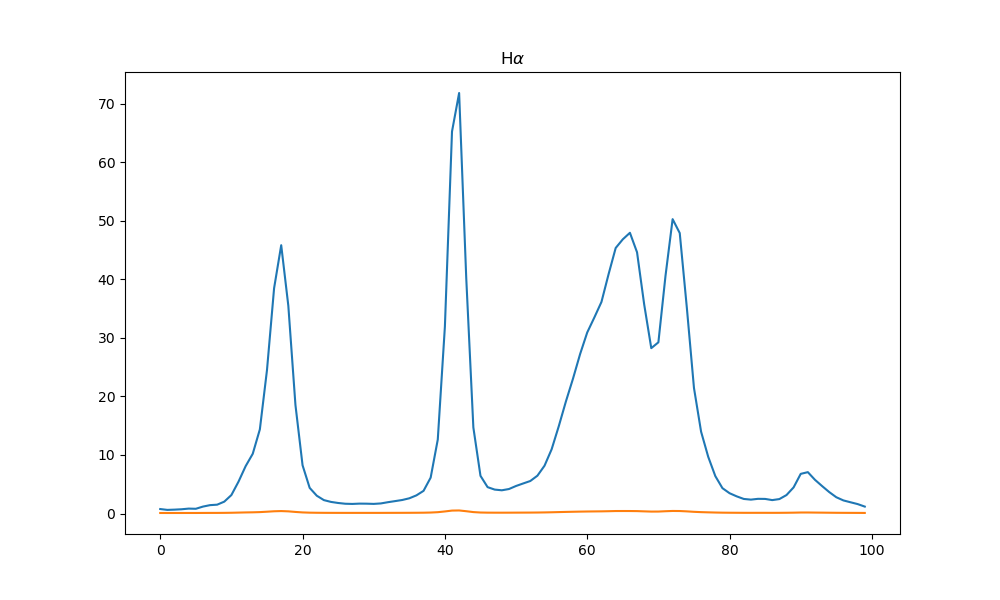

In [22]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.04263
l_HA = 6563 * (1+z)

mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [23]:
n_component = 6

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, theta):
    # theta è un array 1D o DataFrame
    if isinstance(theta, np.ndarray):
        params = theta
    else:
        params = theta.values.flatten()
    
    x_hr = np.linspace(min(x), max(x), 4000)
    
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def LogLikelihood(x, theta, sigma_y, y):
    model_values = model_convolved(x, sigmas[4], theta)
    return -0.5 * np.sum((y - model_values)**2 / sigma_y**2)
    
def Logprior(theta):
    # theta è un array 1D con shape (24,)
    # Riorganizza in shape (4, 6) per avere [I, r, n, x0] per 6 componenti
    if isinstance(theta, np.ndarray):
        params_array = theta.reshape(4, 6)
    else:
        params_array = theta.values.reshape(4, 6)
    
    I = params_array[0]
    r = params_array[1]
    n = params_array[2]
    x0 = params_array[3]
    
    if (np.all((Imin <= I) & (I <= Imax)) and 
        np.all((rmin <= r) & (r <= rmax)) and 
        np.all((nmin <= n) & (n <= nmax)) and 
        np.all((x0min <= x0) & (x0 <= x0max))):
        return 0.0
    else:
        return -np.inf
                  
def LogPosterior(theta, x, sigma_y, y):
    lp = Logprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + LogLikelihood(x, theta, sigma_y, y)

In [24]:
params = pd.read_csv("Halpha_fit.csv", index_col=0)
errors = pd.read_csv("Halpha_fit_errors.csv", index_col=0)
I = params.iloc[0].to_numpy()
r = params.iloc[1].to_numpy()
n = params.iloc[2].to_numpy()
x0 = params.iloc[3].to_numpy()

In [25]:
I_err = errors.iloc[0].to_numpy()
r_err = errors.iloc[1].to_numpy()
n_err = errors.iloc[2].to_numpy()
x0_err = errors.iloc[3].to_numpy()

Imin, Imax = np.zeros(len(I)), np.zeros(len(I))
rmin, rmax = np.zeros(len(I)), np.zeros(len(I))
nmin, nmax = np.zeros(len(I)), np.zeros(len(I))
x0min, x0max = np.zeros(len(I)), np.zeros(len(I))

Imin = np.maximum(0, I - I_err)
Imax = I + I_err

rmin = np.maximum(0, r - r_err)
rmax = r + r_err

nmin = np.maximum(0, n - n_err)
nmax = n + n_err

x0min = np.maximum(0, x0 - x0_err)
x0max = x0 + x0_err

#Compute the loglike e logpost
loglike = LogLikelihood(x_axes, params, real_errors_HA, radial_profile_HA)
logpost = LogPosterior(params.values.flatten(), x_axes, real_errors_HA, radial_profile_HA)

In [38]:
#MCMC with emcee
params_init = params.values.flatten()  

ndim = len(params_init)  
nwalkers = 75  
burn = 10000
nsteps = 100000

# Inizializza i walkers attorno ai valori iniziali
errors_flat = errors.values.flatten()
starting_guesses = params_init + 0.01 * errors_flat * np.random.randn(nwalkers, ndim)

# Crea il sampler
backend = emcee.backends.HDFBackend("MCMC_params.h5")
backend.reset(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, 
                                args=[x_axes, real_errors_HA, radial_profile_HA],\
                                        moves=[(emcee.moves.DEMove(), 0.7), (emcee.moves.DESnookerMove(), 0.3)], threads = -1, backend=backend)
print("Inizio MCMC...")
sampler.run_mcmc(starting_guesses, nsteps, progress=True, store=True)
print("MCMC completato!")

Inizio MCMC...


 22%|███████████████▊                                                         | 21616/100000 [47:28<2:52:07,  7.59it/s]


PermissionError: [Errno 13] Unable to synchronously open file (unable to open file: name = 'MCMC_params.h5', errno = 13, error message = 'Permission denied', flags = 1, o_flags = 2)

In [ ]:
#Visualization of each chain
fig, axes = plt.subplots(24, figsize=(16, 40), sharex=True)
axes = axes.flatten()  # Converti in array 1D per iterare facilmente
samples = sampler.get_chain()

labels = ['I1', 'I2', 'I3', 'I4', 'I5', 'I6',
          'r1', 'r2', 'r3', 'r4', 'r5', 'r6',
          'n1', 'n2', 'n3', 'n4', 'n5', 'n6',
          'x01', 'x02', 'x03', 'x04', 'x05', 'x06']

for i in range(ndim):
    axes[i].plot(samples[:, :, i], "k", alpha=0.3)
    axes[i].set_xlim(0, len(samples))
    axes[i].set_ylabel(labels[i])
    axes[i].yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()
plt.savefig('Chains')

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
#Set the burn-in 
burn = 3*int(max(tau))

#Throw-out the burn-in points and thinning:
samples_burn  = sampler.get_chain(discard=burn, thin=int(max(tau)))

#Plot again the chains
fig, axes = plt.subplots(24, figsize=(16, 40), sharex=True)
axes = axes.flatten()
for i in range(ndim):
    axes[i].plot(samples_burn[:, :, i], "k", alpha=0.3)
    axes[i].set_xlim(0, len(samples_burn))
    axes[i].set_ylabel(labels[i])
    axes[i].yaxis.set_label_coords(-0.1, 0.5)
    axes[i].grid(c='grey', alpha=0.15, ls='--')
plt.savefig('Chains after burn-in and thinning')

In [ ]:
flat_samples = sampler.get_chain(discard=burn, thin=int(max(tau)), flat=True)
np.savetxt

#Corner plot
fig = corner.corner(flat_samples, labels=labels, plot_datapoints = True, levels = [0.68,0.95], 
                    quantiles =[0.05, 0.16, 0.5, 0.84, 0.95], bins = 30, 
                    hist_kwargs={"fill": True, "color": "grey", "alpha": 0.5}, use_math_text=True)